# Specific Task 2.4 Train/Evaluate advanced model

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Reading Data

In [5]:
def read_txt(path):
    rows = []
    with open(path, "r", encoding="utf-8") as fh:
        lines = fh.read().splitlines()
    for line in lines:
        parts = line.split(": ")
        if len(parts) < 4:
            continue
        rows.append({
            "Event Type": parts[0].strip(),
            "Interaction": parts[1].strip(),
            "Feynman Diagram": parts[2].strip(),
            "Amplitude": parts[-2].strip(),
            "Squared Amplitude": parts[-1].strip()
        })
    return rows

In [6]:
base_dir = "/kaggle/input/datasets/arnavtripathi1/symba-test-data"

qed_data = []
qcd_data = []

for file in os.listdir(base_dir):
    path = os.path.join(base_dir, file)
    rows = read_txt(path)
    if "QED" in file:
        qed_data.extend(rows)
    if "QCD" in file:
        qcd_data.extend(rows)

In [7]:
qed_df = pd.DataFrame(qed_data)
qcd_df = pd.DataFrame(qcd_data)

print("QED dataset size:", len(qed_df))
print("QCD dataset size:", len(qcd_df))

QED dataset size: 360
QCD dataset size: 234


# Train-Val-Test Split

In [8]:
from sklearn.model_selection import train_test_split

# split QED
qed_train, temp_df = train_test_split(qed_df, test_size=0.2, random_state=42, shuffle=True)
qed_val, qed_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

# split QCD
qcd_train, temp_df = train_test_split(qcd_df, test_size=0.2, random_state=42, shuffle=True)
qcd_val, qcd_test = train_test_split(temp_df, test_size=0.5, random_state=42, shuffle=True)

print(f"QED -> Train size : {len(qed_train)}, Validation size : {len(qed_val)}, Test size : {len(qed_test)}")
print(f"QCD -> Train size : {len(qcd_train)}, Validation size : {len(qcd_val)}, Test size : {len(qcd_test)}")

qed_train.to_csv("qed_train.csv")
qed_val.to_csv("qed_val.csv")
qed_test.to_csv("qed_test.csv")

qcd_train.to_csv("qcd_train.csv")
qcd_val.to_csv("qcd_val.csv")
qcd_test.to_csv("qcd_test.csv")

QED -> Train size : 288, Validation size : 36, Test size : 36
QCD -> Train size : 187, Validation size : 23, Test size : 24


# Tokenizer

In [9]:
import json
from collections import Counter, OrderedDict
import re
import unicodedata
import warnings
from typing import List, Tuple, Dict, Any
from tqdm.auto import tqdm

class PittTokenizer:
    """Physics-informed tokenizer for amplitudes and squared amplitudes expressions."""
    def __init__(
        self,
        index_token_pool_size = 120,
        momentum_token_pool_size = 10,
        particle_index_pool_size = 10,
        special_symbols = None,
        unk_idx = 3
    ):
        self.index_pool_size = int(index_token_pool_size)
        self.momentum_pool_size = int(momentum_token_pool_size)
        self.particle_index_pool_size = int(particle_index_pool_size)
        self.index_tokens = [f"INDEX_{i}" for i in range(self.index_pool_size)]
        self.momentum_tokens = [f"MOMENTUM_{i}" for i in range(self.momentum_pool_size)]
        self.pindex_tokens = [f"PINDEX_{i}" for i in range(self.particle_index_pool_size)]
        self.special_symbols = special_symbols or ["<BOS>", "<PAD>", "<EOS>", "<UNK>", "<SEP>"]
        self.unk_idx = unk_idx

        # regex patterns
        self._re_whitespace = re.compile(r"\s+")
        self._re_unicode_norm = unicodedata.normalize
        self._re_gamma_token = re.compile(r'gamma_\{([^}]+)\}')
        self._re_wavefunction = re.compile(r'\b([A-Za-z]+)_\{([^}]+)\}\(([^)]+)\)(_[A-Za-z]+)(\^CONJ)?')
        self._re_momentum = re.compile(r'\bp_(\d+)\b')
        self._re_mandelstam = re.compile(r'\bs_(\d+)\b')
        self._re_mass = re.compile(r'\bm_[A-Za-z]+\b')
        self._re_particle_index = re.compile(r'\b([ijkl])_(\d+)\b')
        # candidate indices excluding mass/momentum/mandelstam/particle indices
        self._re_index_candidate = re.compile(r'(?!p_)(?!s_)(?!m_)(?![ijkl]_)[A-Za-z%\\]+_\d+')
        # operators and separators
        self._operators = list('/+-*^,{}()[]:=') 

    # ---- Normalization Utilities ----
    def normalize_unicode_and_whitespace(self, expression):
        """Apply unicode normalization and collapse whitespace."""
        if expression is None:
            return ""
        expr = self._re_unicode_norm("NFKC", expression)
        expr = self._re_whitespace.sub(" ", expr).strip()
        return expr

    def fix_brace_spaces(self, expr):
        """Canonicalize spacing inside {...} blocks:"""
        def clean(match):
            inner = match.group(1)
            inner = inner.strip()
            inner = re.sub(r'\s*,\s*', ',', inner)
            inner = re.sub(r'\s*\+\s*', '+', inner)
            inner = re.sub(r'\s*-\s*', '-', inner)
            return '{' + inner + '}'
        return re.sub(r'\{([^}]*)\}', clean, expr)

    def preprocess_expression(self, expression):
        """Canonicalize common physics tokens and simple formatting."""
        expr = self.normalize_unicode_and_whitespace(str(expression))
        expr = expr.replace("me", "m_e")
        expr = expr.replace("reg_prop", "REG_PROP")
        expr = expr.replace("(*)", "CONJ")
        expr = expr.replace("+-", "-").replace("-+", "-")
        expr = re.sub(r'\s*\*\s*', '*', expr)
        expr = re.sub(r'\s*/\s*', '/', expr)
        expr = re.sub(r'\s*\^\s*', '^', expr)
        expr = re.sub(r'\s*\+\s*', ' + ', expr)
        expr = re.sub(r'\s*-\s*', ' - ', expr)
        expr = re.sub(r'\s+', ' ', expr).strip()
        expr = self.fix_brace_spaces(expr)
        return expr

    def physics_aware_replace(self, expr):
        """Canonicalize momentum, mandelstam, masses, conjugation, imaginary unit and constants."""
        e = expr
        e = self._re_mandelstam.sub(r"MANDELSTAM_\1", e)
        e = self._re_momentum.sub(r"P_\1", e)
        e = self._re_mass.sub(lambda m: m.group(0), e)
        e = re.sub(r'\bi\b(?!\w)', 'I_UNIT', e)
        e = re.sub(r'\be\b(?=\^|[+\-*/()| ,])', 'E_CHARGE', e)
        e = re.sub(r'\bg\b(?=\^|[+\-*/()| ,])', 'G_COUPLING', e)
        return e

    # ---- Index Normalisation and Mapping ----
    def extract_pair_index_order(self, amp, sqamp):
        """Return ordered unique candidate indices, particle indices and momentum matches for a pair."""
        combined = amp + " || " + sqamp
        # find regular index candidates
        seen = OrderedDict()
        for m in self._re_index_candidate.finditer(combined):
            key = m.group(0)
            if key not in seen:
                seen[key] = None
        index_candidates = list(seen.keys())
        # particle indices
        pseen = OrderedDict()
        for m in self._re_particle_index.finditer(combined):
            key = m.group(0)
            if key not in pseen:
                pseen[key] = None
        particle_candidates = list(pseen.keys())
        # momentum occurrences
        mseen = OrderedDict()
        for m in self._re_momentum.finditer(combined):
            key = m.group(0)
            if key not in mseen:
                mseen[key] = None
        momentum_candidates = list(mseen.keys())

        return index_candidates, particle_candidates, momentum_candidates

    def build_deterministic_mapping(self, index_candidates, particle_candidates, momentum_candidates):
        """Create deterministic mapping to INDEX_/PINDEX_/MOMENTUM_ tokens."""
        mapping = {}
        for i, old in enumerate(index_candidates):
            if i >= self.index_pool_size:
                raise RuntimeError("index_pool exhausted; increase index_token_pool_size")
            mapping[old] = self.index_tokens[i]
        for i, old in enumerate(particle_candidates):
            if i >= self.particle_index_pool_size:
                raise RuntimeError("particle_index_pool exhausted; increase particle_index_pool_size")
            mapping[old] = self.pindex_tokens[i]
        for i, old in enumerate(momentum_candidates):
            if i >= self.momentum_pool_size:
                raise RuntimeError("momentum_pool exhausted; increase momentum_token_pool_size")
            mapping[old] = self.momentum_tokens[i]
        return mapping

    def apply_mapping_to_text(self, text, mapping):
        """Replace all full-token matches in text using provided mapping."""
        if not mapping:
            return text
        for old in sorted(mapping.keys(), key=len, reverse=True):
            new = mapping[old]
            text = text.replace(old, new)
        return text

    def normalize_pair_indices(self, ampl, sqamp):
        """Pre-processes and returns strictly mapped strings."""
        amp_p = self.preprocess_expression(ampl)
        sqamp_p = self.preprocess_expression(sqamp)
        idx_cands, p_cands, m_cands = self.extract_pair_index_order(amp_p, sqamp_p)
        mapping = self.build_deterministic_mapping(idx_cands, p_cands, m_cands)
        amp_mapped = self.apply_mapping_to_text(amp_p, mapping)
        sqamp_mapped = self.apply_mapping_to_text(sqamp_p, mapping)
        amp_final = self.physics_aware_replace(amp_mapped)
        sqamp_final = self.physics_aware_replace(sqamp_mapped)
        amp_final = self.fix_brace_spaces(amp_final)
        sqamp_final = self.fix_brace_spaces(sqamp_final)
        return amp_final, sqamp_final, mapping

    def normalize_dataframe_pairs(self, df, keep_mapping=False):
            """Applies normalization to dataframes."""
            records = []
            for _, row in tqdm(df.iterrows(), total=len(df), desc="Normalizing DataFrame Pairs"):
                ampl = row.get("Amplitude", "")
                sqamp = row.get("Squared Amplitude", "")
                ampl_norm, sqamp_norm, mapping = self.normalize_pair_indices(ampl, sqamp)
                rec = row.to_dict()
                rec["Amplitude_norm"] = ampl_norm
                rec["Squared_Amplitude_norm"] = sqamp_norm
                if keep_mapping:
                    rec["index_mapping"] = json.dumps(mapping)
                records.append(rec)
            return pd.DataFrame.from_records(records)
    
    # ---- Splitting Tokens ----
    def expand_structured_tokens(self, text):
        """Expand structured physics tokens by splitting their index/momentum arguments."""
        def _expand_gamma(m):
            inner = m.group(1)
            parts = [p.strip() for p in inner.split(',')]
            return f"GAMMA_{len(parts)} " + " , ".join(parts)
    
        def _expand_wavefunction(m):
            name  = m.group(1).upper()
            inner = m.group(2)
            mom   = m.group(3)
            vtype = m.group(4)
            conj  = " CONJ" if m.group(5) else ""
            parts = [p.strip() for p in inner.split(',')]
            return f"{name}_{len(parts)} " + " , ".join(parts) + f" {mom} {vtype}{conj}"
    
        text = self._re_wavefunction.sub(_expand_wavefunction, text)
        text = self._re_gamma_token.sub(_expand_gamma, text)
        text = re.sub(r'(MOMENTUM_\d+)_(INDEX_\d+)', r'\1 \2', text)
        return text
        
    def split_tokens(self, text):
        """Split on operators and keep tokens intelligible to transformer."""
        t = text
        for op in self._operators:
            t = t.replace(op, f' {op} ')
        # more frequent fractions kept intact
        top_fracs = ["1/2", "1/16", "1/9", "4/9", "1/448", "16/7", "1/144", "1/3", "1/6", "8/7"]
        for f in top_fracs:
            t = re.sub(rf"\b{f.replace('/', ' / ')}\b", f, t)
        t = re.sub(r'\s+', ' ', t).strip()
        tokens = [tok for tok in t.split(' ') if tok]
        return tokens

    def src_tokenize(self, ampl_norm):
        """Tokenize Source expression."""
        if not ampl_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(ampl_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Source tokenization failed for '{ampl_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    def tgt_tokenize(self, sqamp_norm):
        """Tokenize Target expression."""
        if not sqamp_norm: return []
        try:
            expanded_str = self.expand_structured_tokens(str(sqamp_norm))
            tokens = self.split_tokens(expanded_str)
            return tokens
        except Exception as e:
            warnings.warn(f"Target tokenization failed for '{sqamp_norm}': {e}")
            return [self.special_symbols[self.unk_idx]]

    # ---- Build Vocabularies ----
    def get_base_vocab(self):
        """Returns a set of index, momentum and pindex tokens."""
        base = set(self.special_symbols)
        base.update(self.index_tokens)
        base.update(self.momentum_tokens)
        base.update(self.pindex_tokens)
        return base

    def build_src_vocab(self, df: pd.DataFrame) -> set:
        """Build Source Vocabulary."""
        src_vocab = self.get_base_vocab()
        for s in tqdm(df["Amplitude_norm"].astype(str), total=len(df), desc="Building src vocab"):
            src_vocab.update(self.src_tokenize(s))
        return src_vocab

    def build_tgt_vocab(self, df: pd.DataFrame) -> set:
        """Build Target Vocabulary."""
        tgt_vocab = self.get_base_vocab()
        for s in tqdm(df["Squared_Amplitude_norm"].astype(str), total=len(df), desc="Building tgt vocab"):
            tgt_vocab.update(self.tgt_tokenize(s))
        return tgt_vocab

    def save_vocab(self, path, src_vocab, tgt_vocab):
        """Save Vocabularies to JSON file."""
        out = {
            "special_symbols": self.special_symbols,
            "src_vocab": sorted(list(src_vocab)),
            "tgt_vocab": sorted(list(tgt_vocab))
        }
        with open(path, "w", encoding="utf-8") as fh:
            json.dump(out, fh, ensure_ascii=False, indent=2)

    def load_vocab(self, path):
        """Load Vocabularies from JSON file."""
        with open(path, "r", encoding="utf-8") as fh:
            return json.load(fh)

In [10]:
class SymbolicVocab:
    """Simple vocab mapping between tokens and indices."""
    def __init__(self, tokens, special_symbols):
        remaining_tokens = sorted(list(set(tokens) - set(special_symbols)))
        self.token_list = special_symbols + remaining_tokens
        self.token_to_idx = {tok: i for i, tok in enumerate(self.token_list)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
        self.bos_idx = self.token_to_idx.get("<BOS>", 0)
        self.pad_idx = self.token_to_idx.get("<PAD>", 1)
        self.eos_idx = self.token_to_idx.get("<EOS>", 2)
        self.unk_idx = self.token_to_idx.get("<UNK>", 3)
        self.sep_idx = self.token_to_idx.get("<SEP>", 4)
        
    def encode(self, tokens):
        return [self.token_to_idx.get(tok, self.unk_idx) for tok in tokens]

    def decode(self, indices, include_special_tokens = True):
        if include_special_tokens:
            return [self.idx_to_token.get(i, "<UNK>") for i in indices]
        
        specials = {self.pad_idx, self.bos_idx, self.eos_idx, self.sep_idx}
        return [self.idx_to_token.get(i, "<UNK>") for i in indices if i not in specials]

    def __len__(self):
        return len(self.token_list)

# Architecture

In [11]:
import math
from dataclasses import dataclass, asdict
from functools import partial
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [12]:
@dataclass
class Config:
    """Hyperparameters for MAC Encoder-Decoder Transformer."""
    vocab_size:      int
    dim:             int   = 256
    enc_depth:       int   = 3 
    dec_depth:       int   = 3
    ff_expansion:    float = 4.0
    dropout:         float = 0.1
    num_persist_mem: int   = 4
    mem_depth:       int   = 2
    mem_expansion:   float = 4.0
    mem_lr:          float = 0.01
    mem_momentum:    float = 0.9
    mem_decay:       float = 0.01
    mem_chunk_size:  int   = 16
    heads:           int   = 8
    pad_idx:         int   = 1

    def __post_init__(self):
        assert self.dim % self.heads == 0, 'dim must be divisible by heads'
        assert self.mem_chunk_size > 0,    'mem_chunk_size must be > 0'

    def to_dict(self): return asdict(self)


class RMSNorm(nn.Module):
    """Root-mean-square layer normalisation."""
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.g   = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.g


class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    def __init__(self, d_model, dropout=0.1, max_len=2048):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10_000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, offset: int = 0):
        return self.drop(x + self.pe[:, offset:offset + x.size(1)])


class FeedForward(nn.Module):
    """Position-wise feed-forward network with GELU activation."""
    def __init__(self, dim, expansion=4.0, dropout=0.0):
        super().__init__()
        H = int(dim * expansion)
        self.net = nn.Sequential(
            nn.Linear(dim, H), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(H, dim), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)

# Memory Module

In [ ]:
class MemoryMLP(nn.Module):
    """Learnable associative-memory MLP whose weights are the memory state."""
    def __init__(self, dim, depth=2, expansion=4.0, init_std=0.02):
        super().__init__()
        H    = int(dim * expansion)
        dims = [dim] + [H] * (depth - 1) + [dim]
        self.layers   = nn.ModuleList(
            [nn.Linear(din, dout, bias=False) for din, dout in zip(dims[:-1], dims[1:])])
        self.n_layers = len(self.layers)
        for layer in self.layers:
            nn.init.normal_(layer.weight, std=init_std)

    def init_weights(self, device):
        """Return a fresh weight dict (no grad) cloned from current parameters."""
        return {f'layers.{i}.weight': self.layers[i].weight.data.clone().to(device)
                for i in range(self.n_layers)}

    def forward_with_weights(self, x, weight_dict):
        """Forward pass using an external weight dict (for meta-learning)."""
        from torch.func import functional_call
        return functional_call(self, weight_dict, (x,))

    def forward(self, x):
        """Standard forward pass through internal weights."""
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < self.n_layers - 1: x = F.silu(x)
        return x

class NeuralMemory(nn.Module):
    """Titans Neural Memory module with data-dependent learning-rate gates."""
    def __init__(self, dim, depth=2, expansion=4.0,
                 base_lr=0.01, base_momentum=0.9, base_decay=0.01, init_std=0.02):
        super().__init__()
        self.mlp        = MemoryMLP(dim, depth, expansion, init_std)
        self.to_k       = nn.Linear(dim, dim, bias=False)
        self.to_v       = nn.Linear(dim, dim, bias=False)
        self.to_q       = nn.Linear(dim, dim, bias=False)
        self.to_out     = nn.Linear(dim, dim, bias=False)
        self.norm_k     = RMSNorm(dim)
        self.norm_v     = RMSNorm(dim)
        self.norm_q     = RMSNorm(dim)
        self.gate_lr    = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_mom   = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.gate_decay = nn.Sequential(nn.Linear(dim, 1), nn.Sigmoid())
        self.base_lr       = base_lr
        self.base_momentum = base_momentum
        self.base_decay    = base_decay

    def init_state(self, device):
        """Initialise memory state: weight tensors and zero momentum."""
        ws = self.mlp.init_weights(device)
        return {'weights': ws, 'momentum': {k: torch.zeros_like(v) for k, v in ws.items()}}

    def retrieve(self, x, state):
        """Read from memory: M*(q) via the MLP with current weight state."""
        q = self.norm_q(self.to_q(x))
        return self.to_out(self.mlp.forward_with_weights(q, state['weights']))

    def update(self, x, state):
        """Update memory weights via associative-memory gradient descent."""
        k   = self.norm_k(self.to_k(x))
        v   = self.norm_v(self.to_v(x))
        ctx = x.mean(dim=1, keepdim=True)                        # (B, 1, d)
        theta = self.gate_lr(ctx).mean()    * self.base_lr
        eta   = self.gate_mom(ctx).mean()   * self.base_momentum
        alpha = self.gate_decay(ctx).mean() * self.base_decay

        w_keys   = list(state['weights'].keys())
        w_leaves = [state['weights'][k].detach().requires_grad_(True) for k in w_keys]
        w_dict   = dict(zip(w_keys, w_leaves))

        with torch.enable_grad():
            pred  = self.mlp.forward_with_weights(k, w_dict)
            loss  = F.mse_loss(pred, v)
            grads = torch.autograd.grad(loss, w_leaves, create_graph=True)

        new_mom = {k: eta * state['momentum'][k] + (-g)
                   for k, g in zip(w_keys, grads)}
        new_wts = {k: (1 - alpha) * state['weights'][k] + theta * new_mom[k]
                   for k in w_keys}
        return {'weights': new_wts, 'momentum': new_mom}

# Memory As Context

In [ ]:
class MACAttention(nn.Module):
    """Multi-head attention over [prefix || x]."""
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads
        self.dk    = dim // heads
        self.Wq    = nn.Linear(dim, dim, bias=False)
        self.Wk    = nn.Linear(dim, dim, bias=False)
        self.Wv    = nn.Linear(dim, dim, bias=False)
        self.Wo    = nn.Linear(dim, dim, bias=False)
        self.drop  = dropout

    def forward(self, x, prefix=None, attn_mask=None, past_x_kv=None, use_cache=False):
        B, S, _ = x.shape
        h, dk   = self.heads, self.dk

        def split(t, n):
            return t.view(B, n, h, dk).transpose(1, 2)

        q = split(self.Wq(x), S)

        k_x = split(self.Wk(x), S)
        v_x = split(self.Wv(x), S)

        if past_x_kv is not None:
            past_k_x, past_v_x = past_x_kv
            k_x = torch.cat([past_k_x, k_x], dim=2) 
            v_x = torch.cat([past_v_x, v_x], dim=2)

        new_x_kv = (k_x, v_x) if use_cache else None

        # [prefix K/V || accumulated x K/V]
        if prefix is not None:
            P   = prefix.shape[1]
            k   = torch.cat([split(self.Wk(prefix), P), k_x], dim=2)
            v   = torch.cat([split(self.Wv(prefix), P), v_x], dim=2)
        else:
            k = k_x
            v = v_x

        out = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=attn_mask,
            dropout_p=self.drop if self.training else 0.0,
        )
        return self.Wo(out.transpose(1, 2).reshape(B, S, h * dk)), new_x_kv


class MACBlock(nn.Module):
    """One Titans MAC block implementing Equations 21-25 from original Paper."""

    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.norm    = RMSNorm(cfg.dim)
        self.memory  = NeuralMemory(cfg.dim, cfg.mem_depth, cfg.mem_expansion,
                                    cfg.mem_lr, cfg.mem_momentum, cfg.mem_decay)
        self.attn    = MACAttention(cfg.dim, cfg.heads, cfg.dropout)
        self.persist = nn.Parameter(torch.randn(cfg.num_persist_mem, cfg.dim) * 0.02) \
                       if cfg.num_persist_mem > 0 else None
        self.chunk_size = cfg.mem_chunk_size

    def forward(self, x, state, seq_attn_mask=None, past_x_kv=None, use_cache=False):
        B, S, _ = x.shape
        x_n     = self.norm(x)

        all_o: list          = []
        current_state        = state
        
        accumulated_x_kv     = past_x_kv

        for c_start in range(0, S, self.chunk_size):
            c_end    = min(c_start + self.chunk_size, S)
            C        = c_end - c_start
            is_last  = (c_end == S)

            xc_n     = x_n[:, c_start:c_end] 
            xc       = x[:, c_start:c_end]
            past_len = c_start             

            # retrieve from state BEFORE this chunk
            h_t = self.memory.retrieve(xc_n, current_state) 

            # build prefix [persistent || h_t_chunk]
            if self.persist is not None:
                p      = self.persist.unsqueeze(0).expand(B, -1, -1)  
                Np     = p.shape[1]
                prefix = torch.cat([p, h_t], dim=1)                    
            else:
                Np     = 0
                prefix = h_t                  

            # Build attention mask 
            if seq_attn_mask is not None:
                if seq_attn_mask.dim() == 2:       
                    persist_cols = torch.ones (C, Np,       device=x.device, dtype=torch.bool)
                    h_t_cols     = torch.eye  (C,C)
                    # past_x_cols  = torch.ones (C, past_len, device=x.device, dtype=torch.bool)
                    curr_x_cols  = torch.tril (torch.ones(C, C, device=x.device, dtype=torch.bool))
                    full_mask    = torch.cat([persist_cols, h_t_cols,
                                             curr_x_cols], dim=-1)
                else:                                
                    persist_cols  = torch.ones(B, 1, C, Np, device=x.device, dtype=torch.bool)
                    h_t_cols      = torch.eye(C, device=x.device, dtype=torch.bool) \
                                        .unsqueeze(0).unsqueeze(0).expand(B, 1, -1, -1)

                    past_x_cols   = seq_attn_mask[:, :, c_start:c_end, :c_start]  

                    curr_x_pad    = seq_attn_mask[:, :, c_start:c_end, c_start:c_end]
                    curr_x_causal = torch.tril(torch.ones(C, C, device=x.device, dtype=torch.bool)) \
                                        .unsqueeze(0).unsqueeze(0)
                    curr_x_cols   = curr_x_pad & curr_x_causal
                    full_mask     = torch.cat([persist_cols, h_t_cols,
                                              past_x_cols, curr_x_cols], dim=-1)
            else:
                full_mask = None                      

            # attention over [prefix || past_x || curr_x] 
            need_cache   = use_cache or not is_last
            attn_out, new_x_kv = self.attn(
                xc_n, prefix=prefix, attn_mask=full_mask,
                past_x_kv=None, use_cache=False,
            )
            yc = xc + attn_out   # residual

            # Update memory
            current_state = self.memory.update(yc, current_state)

            # Then retrieve
            gate  = self.memory.retrieve(yc, current_state)
            o_c   = yc * gate
            all_o.append(o_c)

            # accumulated_x_kv = new_x_kv

        o_t = torch.cat(all_o, dim=1) 

        # final_x_kv = accumulated_x_kv if use_cache else None
        return o_t, current_state, None

# Multi-Head Attention

In [15]:
def make_causal_mask(seq_len: int, device) -> torch.Tensor:
    """Lower-triangular boolean causal mask (True=attend)."""
    return torch.tril(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool))

class StandardMHA(nn.Module):
    """Standard multi-head attention."""
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads = heads
        self.dk    = dim // heads
        self.Wq    = nn.Linear(dim, dim, bias=False)
        self.Wk    = nn.Linear(dim, dim, bias=False)
        self.Wv    = nn.Linear(dim, dim, bias=False)
        self.Wo    = nn.Linear(dim, dim, bias=False)
        self.drop  = dropout

    def forward(self, q, kv=None, attn_mask=None, past_kv=None, use_cache=False, frozen_kv=False):
        B, Sq, _ = q.shape
        h, dk    = self.heads, self.dk

        def split(t, n): return t.view(B, n, h, dk).transpose(1, 2)

        Q = split(self.Wq(q), Sq)

        if frozen_kv:
            assert past_kv is not None, "frozen_kv=True requires past_kv to be set"
            K, V = past_kv
            new_kv = past_kv
        else:
            if kv is None: kv = q
            Sk = kv.shape[1]
            K  = split(self.Wk(kv), Sk)
            V  = split(self.Wv(kv), Sk)

            if past_kv is not None:
                past_K, past_V = past_kv
                K = torch.cat([past_K, K], dim=2)
                V = torch.cat([past_V, V], dim=2)

            new_kv = (K, V) if use_cache else None

        out = F.scaled_dot_product_attention(
            Q, K, V,
            attn_mask=attn_mask,
            dropout_p=self.drop if self.training else 0.0,
        )
        return self.Wo(out.transpose(1, 2).reshape(B, Sq, h * dk)), new_kv

# Encoder & Decoder

In [ ]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.norm1 = RMSNorm(cfg.dim)
        self.attn  = StandardMHA(cfg.dim, cfg.heads, cfg.dropout)
        self.norm2 = RMSNorm(cfg.dim)
        self.ff    = FeedForward(cfg.dim, cfg.ff_expansion, cfg.dropout)

    def forward(self, x, src_key_mask=None):
        attn_out, _ = self.attn(self.norm1(x), attn_mask=src_key_mask)
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x


class TransformerEncoder(nn.Module):
    """Stack of TransformerEncoderLayers with final RMSNorm."""
    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.layers = nn.ModuleList([TransformerEncoderLayer(cfg) for _ in range(cfg.enc_depth)])
        self.norm   = RMSNorm(cfg.dim)

    def forward(self, x, src_key_mask=None):
        for layer in self.layers:
            x = layer(x, src_key_mask=src_key_mask)
        return self.norm(x)

class MACDecoderLayer(nn.Module):
    """Decoder layer with MAC placed between the FFN and cross-attention."""
    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.norm_sa    = RMSNorm(cfg.dim)
        self.self_attn  = StandardMHA(cfg.dim, cfg.heads, cfg.dropout)
        self.norm_ff    = RMSNorm(cfg.dim)
        self.ff         = FeedForward(cfg.dim, cfg.ff_expansion, cfg.dropout)
        self.mac        = MACBlock(cfg)
        self.norm_mac   = RMSNorm(cfg.dim)
        self.norm_ca    = RMSNorm(cfg.dim)
        self.cross_attn = StandardMHA(cfg.dim, cfg.heads, cfg.dropout)

    def forward(self, tgt, memory, state,
                causal_mask=None, cross_mask=None,
                past_sa_kv=None, cross_kv=None, past_mac_x_kv=None, use_cache=False):
        # 1. Causal self-attention
        sa_out, new_sa_kv = self.self_attn(
            self.norm_sa(tgt),
            attn_mask=causal_mask,
            past_kv=past_sa_kv,
            use_cache=use_cache,
        )
        x = tgt + sa_out

        # 2. Feed-forward
        x = x + self.ff(self.norm_ff(x))

        # 3. MAC block
        x_pre_mac = x
        mac_out, new_state, new_mac_x_kv = self.mac(
            x_pre_mac, state,
            seq_attn_mask=causal_mask,
            past_x_kv=past_mac_x_kv,
            use_cache=use_cache,
        )
        x = self.norm_mac(x_pre_mac + mac_out)

        # 4. Cross-attention
        if cross_kv is not None:
            ca_out, new_cross_kv = self.cross_attn(
                self.norm_ca(x),
                kv=None,
                attn_mask=cross_mask,
                past_kv=cross_kv,
                use_cache=True,
                frozen_kv=True,
            )
        else:
            ca_out, new_cross_kv = self.cross_attn(
                self.norm_ca(x),
                kv=memory,
                attn_mask=cross_mask,
                past_kv=None,
                use_cache=use_cache,
            )
        x = x + ca_out

        return x, new_state, new_sa_kv, new_cross_kv, new_mac_x_kv

class MACDecoder(nn.Module):
    """Stack of MACDecoderLayers with a final RMSNorm."""

    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.layers = nn.ModuleList([MACDecoderLayer(cfg) for _ in range(cfg.dec_depth)])
        self.norm   = RMSNorm(cfg.dim)

    def _init_states(self, device):
        """One independent NeuralMemory state per decoder layer."""
        return [layer.mac.memory.init_state(device) for layer in self.layers]

    def forward(self, tgt, memory, causal_mask=None, cross_mask=None):
        """Training forward: no KV caching (use_cache=False default in each layer)."""
        device = tgt.device
        states = self._init_states(device)
        x = tgt
        for i, layer in enumerate(self.layers):
            x, states[i], _, _, _ = layer(
                x, memory, states[i],
                causal_mask=causal_mask, cross_mask=cross_mask,
            )
        return self.norm(x)


# MAC Encoder-Decoder
class MACEncoderDecoder(nn.Module):
    """Encoder-Decoder Transformer with Titans MAC in the decoder."""
    def __init__(self, cfg: 'Config'):
        super().__init__()
        self.cfg     = cfg
        self.embed   = nn.Embedding(cfg.vocab_size, cfg.dim, padding_idx=cfg.pad_idx)
        self.pe      = PositionalEncoding(cfg.dim, cfg.dropout)
        self.encoder = TransformerEncoder(cfg)
        self.decoder = MACDecoder(cfg)
        self.lm_head = nn.Linear(cfg.dim, cfg.vocab_size, bias=False)
        self.scale   = math.sqrt(cfg.dim)
        nn.init.normal_(self.embed.weight, std=0.02)
        with torch.no_grad():
            self.embed.weight[cfg.pad_idx].fill_(0)

    def _embed(self, ids, offset: int = 0):
        return self.pe(self.embed(ids) * self.scale, offset=offset)

    def _encode(self, src_ids, src_mask=None):
        cross_mask = None
        if src_mask is not None:
            cross_mask = src_mask.unsqueeze(1).unsqueeze(2)   # (B,1,1,Ss)
        src_key_mask = cross_mask
        memory = self.encoder(self._embed(src_ids), src_key_mask=src_key_mask)
        return memory, cross_mask

    def forward(self, src_ids, tgt_ids, labels=None, src_mask=None):
        St     = tgt_ids.shape[1]
        device = src_ids.device

        memory, cross_mask = self._encode(src_ids, src_mask)

        causal_mask = make_causal_mask(St, device)
        out = self.decoder(self._embed(tgt_ids), memory,
                           causal_mask=causal_mask, cross_mask=cross_mask)

        logits = self.lm_head(out)

        if labels is None:
            return logits

        return F.cross_entropy(
            logits.reshape(-1, self.cfg.vocab_size),
            labels.reshape(-1),
            ignore_index=self.cfg.pad_idx,
        )

    @torch.no_grad()
    def greedy_generate(self, src_ids, bos_idx, max_new_tokens=2024,
                        eos_idx=None, device=None, tgt_logit_mask=None):
        """Greedy autoregressive decode with full KV caching."""
        self.eval()
        device = device or next(self.parameters()).device
        if not torch.is_tensor(src_ids):
            src_ids = torch.tensor(src_ids, dtype=torch.long)
        if src_ids.dim() == 1:
            src_ids = src_ids.unsqueeze(0)
        src_ids = src_ids.to(device)
        B = src_ids.shape[0]

        results = []
        for b in range(B):
            s_ids = src_ids[b:b+1]

            memory, cross_mask = self._encode(s_ids, src_mask=None)

            gen = torch.full((1, 1), bos_idx, dtype=torch.long, device=device)

            past_sa_kv    = [None] * len(self.decoder.layers)
            cross_kv      = [None] * len(self.decoder.layers)
            past_mac_x_kv = [None] * len(self.decoder.layers)
            mem_states    = self.decoder._init_states(device)

            for _ in range(max_new_tokens):
                new_tok = gen[:, -1:]
                pos     = gen.shape[1] - 1
                x = self._embed(new_tok, offset=pos)

                for i, layer in enumerate(self.decoder.layers):
                    x, mem_states[i], new_sa_kv, new_cross_kv, new_mac_x_kv = layer(
                        x, memory, mem_states[i],
                        causal_mask=None,
                        cross_mask=cross_mask,
                        past_sa_kv=past_sa_kv[i],
                        cross_kv=cross_kv[i],
                        past_mac_x_kv=past_mac_x_kv[i],
                        use_cache=True,
                    )
                    past_sa_kv[i]    = new_sa_kv
                    past_mac_x_kv[i] = new_mac_x_kv
                    if cross_kv[i] is None:
                        cross_kv[i] = new_cross_kv

                x    = self.decoder.norm(x)
                logits = self.lm_head(x)[:, -1]
                if tgt_logit_mask is not None:
                    logits = logits + tgt_logit_mask.to(device)
                next_tok = int(logits.argmax(-1).item())
                gen = torch.cat(
                    [gen, torch.tensor([[next_tok]], dtype=torch.long, device=device)], dim=1)
                if eos_idx is not None and next_tok == eos_idx:
                    break

            toks = gen[0, 1:].tolist()
            if eos_idx is not None and eos_idx in toks:
                toks = toks[:toks.index(eos_idx) + 1]
            results.append(toks)

        return results

    def save(self, path, optimizer=None, scheduler=None, history=None):
        payload = {'model': self.state_dict(), 'config': self.cfg.to_dict()}
        if optimizer: payload['optimizer'] = optimizer.state_dict()
        if scheduler: payload['scheduler'] = scheduler.state_dict()
        if history:   payload['history']   = history
        torch.save(payload, path)

    def save_artifacts(self, run_dir, vocab, tok, optimizer=None, scheduler=None, history=None):
        import os, json
        os.makedirs(run_dir, exist_ok=True)
        self.save(os.path.join(run_dir, 'model.pt'), optimizer, scheduler, history)
        vocab_payload = {
            'token_list': vocab.token_list,
            'bos_idx': vocab.bos_idx, 'pad_idx': vocab.pad_idx,
            'eos_idx': vocab.eos_idx, 'unk_idx': vocab.unk_idx,
        }
        with open(os.path.join(run_dir, 'vocab.json'), 'w') as f:
            json.dump(vocab_payload, f, ensure_ascii=False, indent=2)
        tok_cfg = {
            'index_pool':      tok.index_pool_size,
            'momentum_pool':   tok.momentum_pool_size,
            'pindex_pool':     tok.particle_index_pool_size,
            'special_symbols': tok.special_symbols,
        }
        with open(os.path.join(run_dir, 'tok_config.json'), 'w') as f:
            json.dump(tok_cfg, f, indent=2)

    @classmethod
    def load(cls, path, device='cpu'):
        ckpt  = torch.load(path, map_location=device)
        model = cls(Config(**ckpt['config']))
        model.load_state_dict(ckpt['model'])
        return model, ckpt

    @classmethod
    def load_artifacts(cls, run_dir, device='cpu'):
        import os, json
        model, ckpt = cls.load(os.path.join(run_dir, 'model.pt'), device=device)
        with open(os.path.join(run_dir, 'vocab.json')) as f:
            vd = json.load(f)
        vocab = SymbolicVocab.__new__(SymbolicVocab)
        vocab.token_list   = vd['token_list']
        vocab.token_to_idx = {t: i for i, t in enumerate(vocab.token_list)}
        vocab.idx_to_token = {i: t for t, i in vocab.token_to_idx.items()}
        vocab.bos_idx = vd['bos_idx']; vocab.pad_idx = vd['pad_idx']
        vocab.eos_idx = vd['eos_idx']; vocab.unk_idx = vd['unk_idx']
        vocab.sep_idx = vocab.token_to_idx.get('<SEP>', 4)
        with open(os.path.join(run_dir, 'tok_config.json')) as f:
            tc = json.load(f)
        tok = PittTokenizer(
            index_token_pool_size    = tc['index_pool'],
            momentum_token_pool_size = tc['momentum_pool'],
            particle_index_pool_size = tc['pindex_pool'],
            special_symbols          = tc['special_symbols'],
        )
        return model, vocab, tok, ckpt

# Dataset & DataLoader

In [ ]:
class SymbaDataset(Dataset):
    def __init__(self, df, tok, vocab, max_src=2024, max_tgt=2024):
        df = tok.normalize_dataframe_pairs(df)
        self.samples = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc='Encoding'):
            st  = tok.src_tokenize(row['Amplitude_norm'])
            tt  = tok.tgt_tokenize(row['Squared_Amplitude_norm'])
            src   = [vocab.bos_idx] + vocab.encode(st)[:max_src-2] + [vocab.eos_idx]
            tgt   = [vocab.bos_idx] + vocab.encode(tt)[:max_tgt-1]
            label = vocab.encode(tt)[:max_tgt-1] + [vocab.eos_idx]
            self.samples.append((src, tgt, label))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def collate(batch, pad):
    """Pad src, tgt and label sequences to batch-max length; return boolean src_mask."""
    srcs, tgts, lbls = zip(*batch)
    def _pad(seqs):
        ml = max(len(s) for s in seqs)
        return torch.tensor([[*s, *[pad]*(ml-len(s))] for s in seqs], dtype=torch.long)
    src_ids = _pad(srcs)
    tgt_ids = _pad(tgts)
    labels  = _pad(lbls)
    src_mask = (src_ids != pad)
    return src_ids, tgt_ids, labels, src_mask

# Setup

In [18]:
tok = PittTokenizer()

train_norm = tok.normalize_dataframe_pairs(qed_train)
src_vocab  = tok.build_src_vocab(train_norm)
tgt_vocab  = tok.build_tgt_vocab(train_norm)
all_vocab  = src_vocab | tgt_vocab

vocab = SymbolicVocab(all_vocab, tok.special_symbols)
print(f'Vocab: {len(vocab)}  '
      f'src-only: {len(src_vocab - tgt_vocab)}  '
      f'tgt-only: {len(tgt_vocab - src_vocab)}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inference mask; block src-only tokens from being generated
_src_only_ids   = [vocab.token_to_idx[t] for t in (src_vocab - tgt_vocab)
                   if t in vocab.token_to_idx]
tgt_logit_mask  = torch.zeros(len(vocab))
tgt_logit_mask[_src_only_ids] = float('-inf')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Building src vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Building tgt vocab:   0%|          | 0/288 [00:00<?, ?it/s]

Vocab: 205  src-only: 22  tgt-only: 12


In [ ]:
cfg = Config(
    vocab_size      = len(vocab),
    dim             = 256,
    enc_depth       = 2,          
    dec_depth       = 2,      
    heads           = 8,
    ff_expansion    = 4.0,
    dropout         = 0.1,
    num_persist_mem = 4,
    mem_depth       = 2,
    mem_expansion   = 4.0,
    mem_lr          = 0.01,
    mem_momentum    = 0.9,
    mem_decay       = 0.01,
    mem_chunk_size  = 16,        
    pad_idx         = vocab.pad_idx,
)

model = MACEncoderDecoder(cfg).to(device)
n_enc = sum(p.numel() for p in model.encoder.parameters())
n_dec = sum(p.numel() for p in model.decoder.parameters())
n_tot = sum(p.numel() for p in model.parameters())
print(f'Encoder params : {n_enc:,}')
print(f'Decoder params : {n_dec:,}')
print(f'Total params   : {n_tot:,}')

Encoder params : 1,576,704
Decoder params : 4,204,806
Total params   : 5,886,470


In [ ]:
BATCH        = 1
_collate_fn  = partial(collate, pad=vocab.pad_idx)

train_ds = SymbaDataset(qed_train, tok, vocab)
val_ds   = SymbaDataset(qed_val,   tok, vocab)

train_loader = DataLoader(train_ds, BATCH, shuffle=True,  collate_fn=_collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, collate_fn=_collate_fn, num_workers=0)
print(f'Train batches: {len(train_loader)}   Val batches: {len(val_loader)}')

Normalizing DataFrame Pairs:   0%|          | 0/288 [00:00<?, ?it/s]

Encoding:   0%|          | 0/288 [00:00<?, ?it/s]

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding:   0%|          | 0/36 [00:00<?, ?it/s]

Train batches: 288   Val batches: 36


## Training

In [18]:
def run_epoch(loader, train=True):
    """Run one full epoch; return mean loss."""
    model.train(train)
    total_loss = 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for src, tgt, lbl, mask in tqdm(loader, leave=False):
            src, tgt, lbl, mask = (t.to(device) for t in (src, tgt, lbl, mask))
            loss = model(src, tgt, labels=lbl, src_mask=mask)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


def val_seq_acc(loader, n_batches=20):
    """Sequence and token accuracy via greedy decoding."""
    model.eval()
    seq_correct = seq_total = tok_correct = tok_total = 0
    for i, (src, _, lbl, _) in enumerate(loader):
        if i >= n_batches: break
        src   = src.to(device)
        preds = model.greedy_generate(
            src, vocab.bos_idx, eos_idx=vocab.eos_idx,
            device=device, tgt_logit_mask=tgt_logit_mask)
        for j in range(src.shape[0]):
            gold      = [t for t in lbl[j].tolist() if t != vocab.pad_idx]
            pred_toks = preds[j]
            if pred_toks == gold: seq_correct += 1
            seq_total += 1
            for p, g in zip(pred_toks, gold):
                if p == g: tok_correct += 1
            tok_total += len(gold)
    return (seq_correct / seq_total if seq_total else 0.0,
            tok_correct / tok_total if tok_total else 0.0)

In [19]:
EPOCHS    = 250
GRAD_CLIP = 1.0
PATIENCE  = 20
MIN_DELTA = 1e-3
RUN_DIR   = 'mac_enc_dec_qed_run'

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.0)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
history   = {'train_loss': [], 'val_loss': []}

best_val   = float('inf')
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss   = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    improved = val_loss < best_val - MIN_DELTA
    print(f'Epoch {epoch:3d} | train={train_loss:.4f}  val={val_loss:.4f}'
          f'{" *" if improved else ""}')

    if improved:
        best_val, no_improve = val_loss, 0
        model.save_artifacts(RUN_DIR, vocab, tok, optimizer, scheduler, history)
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping after {PATIENCE} epochs without improvement.')
            break

print(f'\nBest val loss: {best_val:.4f}')

model = MACEncoderDecoder.load_artifacts(RUN_DIR, device=str(device))[0].to(device)
model.eval()
history['val_seq_acc'], history['val_tok_acc'] = val_seq_acc(val_loader, n_batches=50)
print(f'Val seq acc:   {history["val_seq_acc"]:.4f}')
print(f'Val tok acc:   {history["val_tok_acc"]:.4f}')

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch   1 | train=3.7338  val=2.9083 *


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch  87 | train=0.0028  val=0.0217


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch  88 | train=0.0031  val=0.0143
Early stopping after 20 epochs without improvement.

Best val loss: 0.0142
Val seq acc:   0.0556
Val tok acc:   0.2298


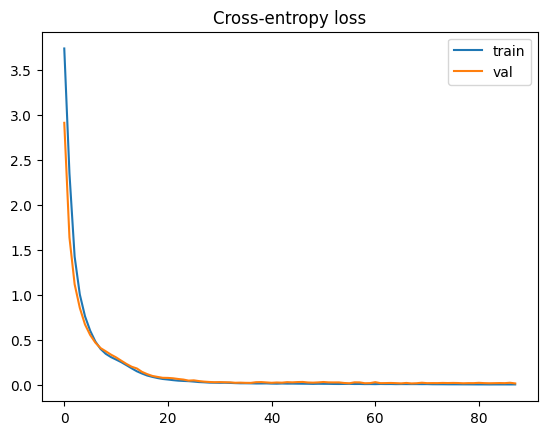

In [20]:
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'],   label='val')
plt.title('Cross-entropy loss')
plt.legend()

plt.show()

# Evaluation

In [21]:
test_ds = SymbaDataset(qed_test, tok, vocab)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, collate_fn=_collate_fn)

test_seq_acc, test_tok_acc = val_seq_acc(test_loader, n_batches=len(test_loader))

print(f'Best Model Test seq acc:   {test_seq_acc:.4f}')
print(f'Best Model Test tok acc:   {test_tok_acc:.4f}')

Normalizing DataFrame Pairs:   0%|          | 0/36 [00:00<?, ?it/s]

Encoding:   0%|          | 0/36 [00:00<?, ?it/s]

Best Model Test seq acc:   0.1944
Best Model Test tok acc:   0.3655
